In [161]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [162]:
class Lor_reservoir:
    def __init__(self, hyperparameters):
        self.num_neurons = hyperparameters.get("num_neurons")
        self.input_connectivity = hyperparameters.get("input_connectivity")
        self.num_steps = hyperparameters.get("num_steps")
        self.input_firing_rate = hyperparameters.get("input_firing_rate")
        self.weight_connectivity = hyperparameters.get("weight_connectivity")
        self.LIF_beta = hyperparameters.get("LIF_beta")
        self.LIF_threshold = hyperparameters.get("LIF_threshold")
        

    def init_weights(self, target_sr):

        # weight matrix for reservoir. Weights drawn from gaussian with mean 0 and std 0.333s, and with 10% connectivity.
        # includes exitatory and inhibitory weights.
        w_res = np.random.normal(0, 0.333, (self.num_neurons, self.num_neurons))

        mask = np.random.rand(self.num_neurons, self.num_neurons) < self.weight_connectivity
        w_res = w_res * mask
        np.fill_diagonal(w_res, 0) # no self-connections

        eigenvalues = np.linalg.eigvals(w_res)
        current_sr = np.max(np.abs(eigenvalues))

        #TODO more on this
        if current_sr > 0: 
            w_res = w_res / current_sr * target_sr

        print(f"initiating weights with spetral radius {target_sr}")

        return w_res
        

    def init_input_weights_full(self, input_dim):
        # shape: (num_neurons, input_dim)
        # random signs and magnitudes, sparse by input_connectivity
        w_in = np.random.uniform(-1, 1, (self.num_neurons, input_dim))
        mask = np.zeros((self.num_neurons, input_dim))
        input_neurons = np.random.choice(
            self.num_neurons,
            size=int(self.num_neurons * self.input_connectivity),
            replace=False
        )
        mask[input_neurons, :] = 1.0
        return w_in * mask

    def gen_spikes(self, rate_tensor):
        random_vals = np.random.random(rate_tensor.shape)
        spikes = (random_vals < rate_tensor).astype(float)
        return spikes
    

    def LIF_res(self, prev_mem, prev_spk, w_res, input_spikes, beta, threshold):

        recurrent_input = w_res @ prev_spk  # (num_neurons,)
        
        total_input = input_spikes + recurrent_input # (num_neurons,)

        spk = (prev_mem > threshold).astype(float)
        mem = beta * prev_mem + total_input - spk * threshold
        
        return mem, spk

In [163]:
def generate_lorenz(num_steps, dt=0.01, sigma=10, rho=28, beta=8/3):
    xyz = np.zeros((num_steps, 3))
    xyz[0] = [1.0, 1.0, 1.0]  # initial condition
    for t in range(num_steps - 1):
        x, y, z = xyz[t]
        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z
        xyz[t+1] = xyz[t] + dt * np.array([dx, dy, dz])
    return xyz

In [164]:
def train_readout_ridge(X_train, Y_train, alpha=1e-4):

    # X_train: (T, N)
    # Y_train: (T, 3)
    T, N = X_train.shape
    w_out = Y_train.T @ X_train @ np.linalg.inv(X_train.T @ X_train + alpha * np.eye(N))
    return w_out  # (3, N)

In [165]:
def nrmse(y_true, y_pred):
    # y_true, y_pred: (T, 3)
    error = np.sqrt(np.mean((y_true - y_pred)**2, axis=0))
    scale = np.std(y_true, axis=0)
    return error / scale  # (3,) — one per coordinate

In [166]:
washout_steps = 200
train_steps   = 700
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200


hp = {
    "num_steps": total_steps,
    "num_neurons": 100,
    "input_firing_rate": 0.4,
    "input_connectivity": 0.3,
    "weight_connectivity": 0.1,
    "LIF_beta": 0.8187,
    "LIF_threshold": 1.0,
}


num_neurons = hp['num_neurons']
num_steps = hp['num_steps']

res = Lor_reservoir(hp)

spectral_lambdas = [0.5, 0.7, 0.9, 1.0, 1.1, 1.3, 1.5]

score_arr = []


for lam in spectral_lambdas:
    print(10*"#")
    print(f"for sr lambda {lam}")

    w_in_weights = res.init_input_weights_full(3) # (num_neurons, 3)
    w_res = res.init_weights(lam)

    lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)

    mem = np.zeros(num_neurons)
    spk = np.zeros(num_neurons)
    spk_rec = np.zeros((num_steps, num_neurons))
    mem_rec = np.zeros((num_steps, num_neurons))

    print(f"ready to sim")

    for t in range(num_steps):

        I = w_in_weights @ lorenz_traj[t] # (100, )

        mem, spk = res.LIF_res(mem, spk, w_res, I, hp["LIF_beta"], hp["LIF_threshold"])
        spk_rec[t] = spk
        mem_rec[t] = mem


    X_train = spk_rec[washout_steps : washout_steps + train_steps]    # (T, N)
    Y_train = lorenz_traj[washout_steps+1 : washout_steps + train_steps+1]  # (T, 3)

    X_test = spk_rec[washout_steps + train_steps : total_steps - 1]   # (T, N)
    Y_test = lorenz_traj[washout_steps + train_steps+1 : total_steps]  # (T, 3)

    print(f"ready to train")

    # train
    w_out = train_readout_ridge(X_train, Y_train, alpha=1e-4)  # (3, N)

    # predict
    Y_pred = (w_out @ X_test.T).T   # (T, 3)

    # score
    scores = nrmse(Y_test, Y_pred)

    #print(f"for lam: {lam}, NRMSE  x:{scores[0]:.3f}  y:{scores[1]:.3f}  z:{scores[2]:.3f}")
    score_arr.append(scores)



##########
for sr lambda 0.5
initiating weights with spetral radius 0.5
ready to sim
ready to train
##########
for sr lambda 0.7
initiating weights with spetral radius 0.7
ready to sim
ready to train
##########
for sr lambda 0.9
initiating weights with spetral radius 0.9
ready to sim
ready to train
##########
for sr lambda 1.0
initiating weights with spetral radius 1.0
ready to sim
ready to train
##########
for sr lambda 1.1
initiating weights with spetral radius 1.1
ready to sim
ready to train
##########
for sr lambda 1.3
initiating weights with spetral radius 1.3
ready to sim
ready to train
##########
for sr lambda 1.5
initiating weights with spetral radius 1.5
ready to sim
ready to train


In [167]:
print(np.shape(score_arr))

(7, 3)


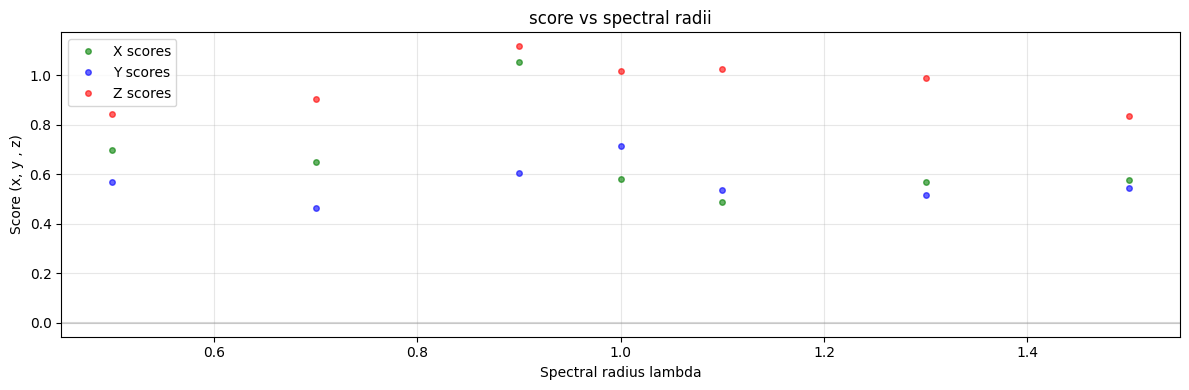

In [168]:
# Create visualization
plt.figure(figsize=(12, 4))

# Plot 1: Scatter plot of all samples
plt.plot(spectral_lambdas, [x[0] for x in score_arr], 'o', alpha=0.6, markersize=4, color="green", label='X scores')
plt.plot(spectral_lambdas, [y[1] for y in score_arr], 'o', alpha=0.6, markersize=4, color="blue", label='Y scores')
plt.plot(spectral_lambdas, [z[2] for z in score_arr], 'o', alpha=0.6, markersize=4, color="red", label='Z scores')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('Score (x, y , z)')
plt.title('score vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [169]:
N = hp['num_neurons']

washout_steps = 200
train_steps   = 700
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200

eps = 1e-6

Lyapunov_arr = []

for lam in spectral_lambdas:
    print(10*"#")
    print(f"for sr lambda {lam}")

    w_in_weights = res.init_input_weights_full(3) # (num_neurons, 3)
    w_res = res.init_weights(lam)

    lorenz_traj = generate_lorenz(num_steps, dt=0.01) # (num_steps, 3)

    # run washout on both, starting from same point
    mem1 = np.zeros(N); spk1 = np.zeros(N)
    mem2 = np.zeros(N); spk2 = np.zeros(N)

    for t in range(washout_steps):
        I = w_in_weights @ lorenz_traj[t]
        # reservoir 1
        mem1, spk1 = res.LIF_res(mem1, spk1, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])
        # reservoir 2
        mem2, spk2 = res.LIF_res(mem2, spk2, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])

    # perturb second reservoir slightly
    mem2 = mem1 + eps * np.random.randn(N)

    log_growth = []

    for t in range(washout_steps, washout_steps + train_steps):
        I = w_in_weights @ lorenz_traj[t]
        # reservoir 1
        mem1, spk1 = res.LIF_res(mem1, spk1, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])
        # reservoir 2
        mem2, spk2 = res.LIF_res(mem2, spk2, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])
        
        dist = np.linalg.norm(mem2 - mem1)
        if dist == 0:
            continue
        
        log_growth.append(np.log(dist / eps))
        
        # renormalize to prevent explosion
        mem2 = mem1 + eps * (mem2 - mem1) / dist
        
    Lyapunov_arr.append(np.mean(log_growth))

##########
for sr lambda 0.5
initiating weights with spetral radius 0.5
##########
for sr lambda 0.7
initiating weights with spetral radius 0.7
##########
for sr lambda 0.9
initiating weights with spetral radius 0.9
##########
for sr lambda 1.0
initiating weights with spetral radius 1.0
##########
for sr lambda 1.1
initiating weights with spetral radius 1.1
##########
for sr lambda 1.3
initiating weights with spetral radius 1.3
##########
for sr lambda 1.5
initiating weights with spetral radius 1.5


In [170]:
print(Lyapunov_arr)

[np.float64(-0.19669201242857456), np.float64(-0.19658782619210205), np.float64(-0.1966324693291609), np.float64(-0.1968182828392779), np.float64(-0.19683713036304237), np.float64(-0.1967193712995207), np.float64(-0.19672080541195117)]


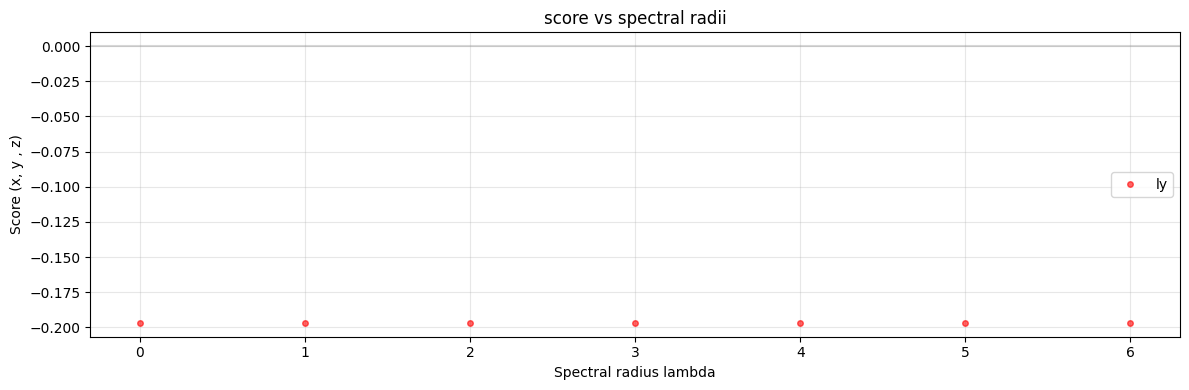

In [ ]:
# Create visualization
plt.figure(figsize=(12, 4))

# Plot 1: Scatter plot of all samples
plt.plot(spectral_lambdas, Lyapunov_arr, 'o', alpha=0.6, markersize=4, color="red", label='ly')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('Lyapunov exponent')
plt.title('Lyapunov exponent vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [172]:


washout_steps = 200
train_steps   = 700
test_steps    = 300
total_steps   = washout_steps + train_steps + test_steps  # 1200

max_delay=50

N = hp['num_neurons']

T = washout_steps + train_steps + max_delay
u = np.random.uniform(-1, 1, T)  # random signal

capacity_arr = []

for lam in spectral_lambdas:
    print(10*"#")
    print(f"for sr lambda {lam}")

    # use a 1D random input for this test, not Lorenz
    w_in_weights_1D = res.init_input_weights_full(1).squeeze() # (num_neurons, 3)
    w_res = res.init_weights(lam)
    
    mem = np.zeros(N); spk = np.zeros(N)
    spk_rec = np.zeros((T, N))
    
    for t in range(T):
        I = w_in_weights_1D * u[t]   # w_in_1d is shape (N,), broadcast
        mem, spk = res.LIF_res(mem, spk, w_res, I, hp['LIF_beta'], hp['LIF_threshold'])
        spk_rec[t] = spk
    
    X = spk_rec[washout_steps:]          # (train_steps + max_delay, N)
    total_mc = 0.0
    
    for k in range(1, max_delay + 1):
        # target: u(t - k), aligned with reservoir states
        x = X[:train_steps]                          # (train_steps, N)
        y = u[washout_steps - k : washout_steps - k + train_steps]  # (train_steps,)
        
        # train tiny readout for this delay
        w = y @ x @ np.linalg.inv(x.T @ x + 1e-4 * np.eye(N))  # (N,)
        y_pred = x @ w                               # (train_steps,)
        
        # memory capacity contribution: squared correlation
        corr = np.corrcoef(y, y_pred)[0, 1]
        mc_k = corr ** 2
        total_mc += mc_k
        
    capacity_arr.append(total_mc)

##########
for sr lambda 0.5
initiating weights with spetral radius 0.5
##########
for sr lambda 0.7
initiating weights with spetral radius 0.7
##########
for sr lambda 0.9
initiating weights with spetral radius 0.9
##########
for sr lambda 1.0
initiating weights with spetral radius 1.0
##########
for sr lambda 1.1
initiating weights with spetral radius 1.1
##########
for sr lambda 1.3
initiating weights with spetral radius 1.3
##########
for sr lambda 1.5
initiating weights with spetral radius 1.5


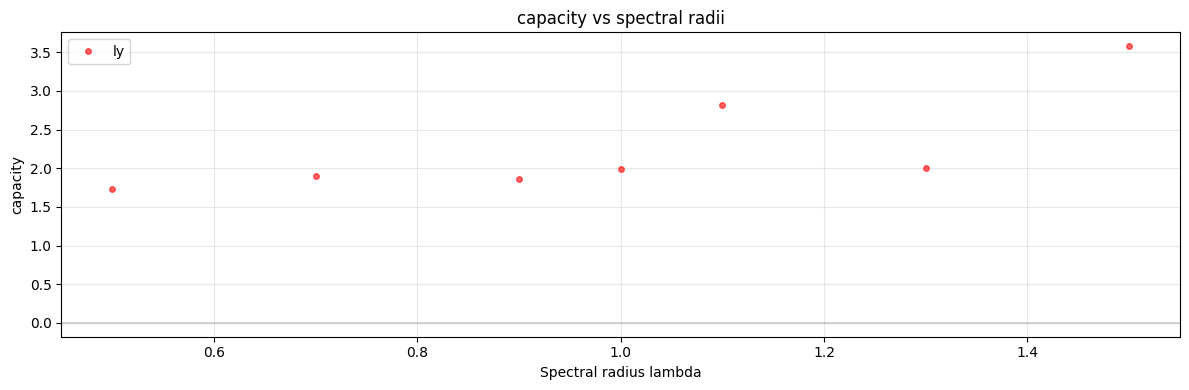

In [174]:
# Create visualization
plt.figure(figsize=(12, 4))

# Plot 1: Scatter plot of all samples
plt.plot(spectral_lambdas, capacity_arr, 'o', alpha=0.6, markersize=4, color="red", label='ly')

plt.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.xlabel('Spectral radius lambda')
plt.ylabel('capacity')
plt.title('capacity vs spectral radii')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()